<a href="https://colab.research.google.com/github/yogimalleswari/data-visuvalization/blob/main/week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [4]:
# If file uploaded directly
df = pd.read_csv('/content/drive/MyDrive/Indian_Kids_Screen_Time.csv')

# If in Drive
# df = pd.read_csv('/content/drive/MyDrive/Indian_Kids_Screen_Time.csv')

df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [6]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['Age', 'Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio'], dtype='object')
Categorical Columns: Index(['Gender', 'Primary_Device', 'Health_Impacts', 'Urban_or_Rural'], dtype='object')


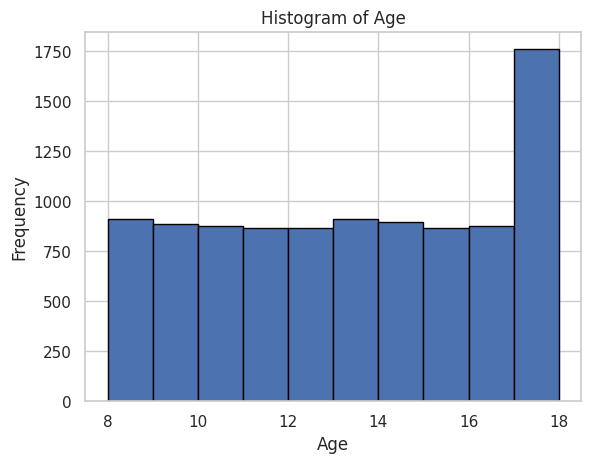

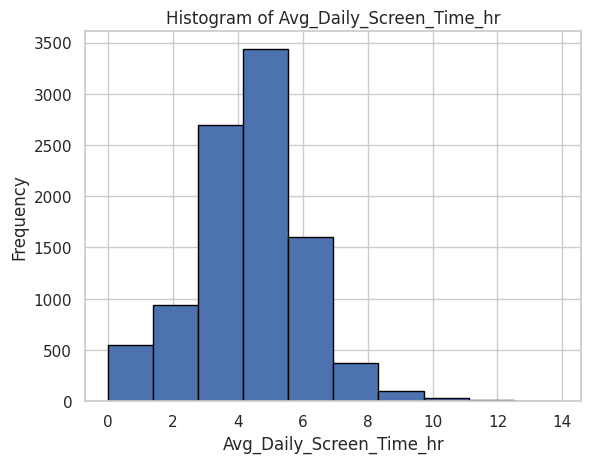

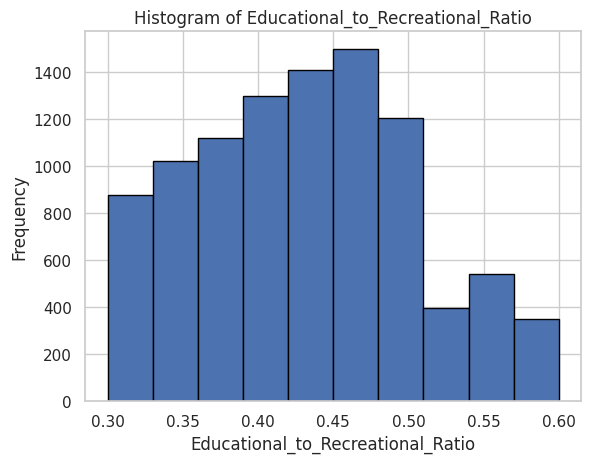

In [17]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=10, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

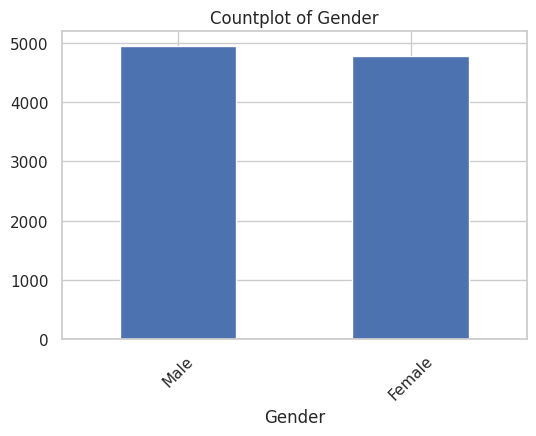

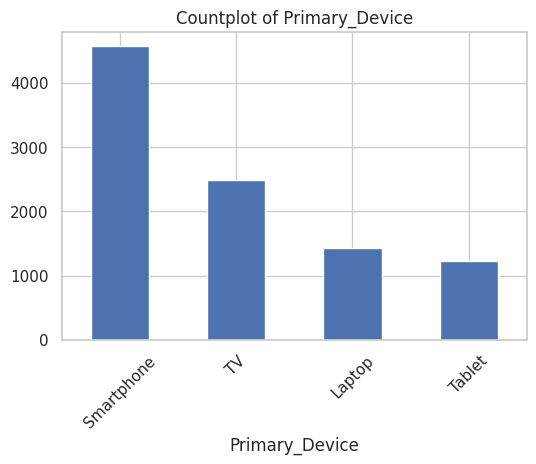

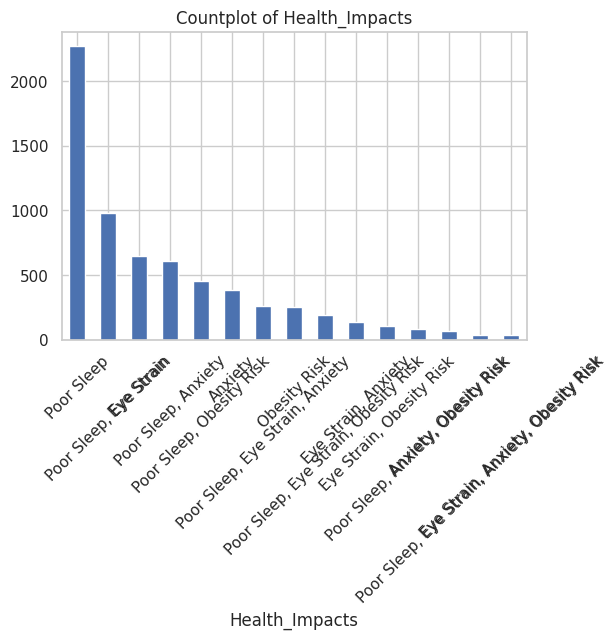

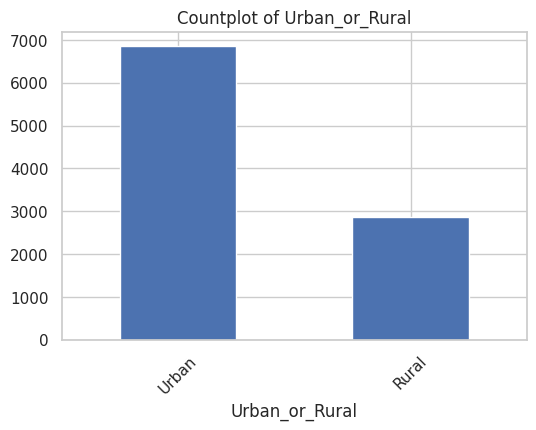

In [8]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.show()

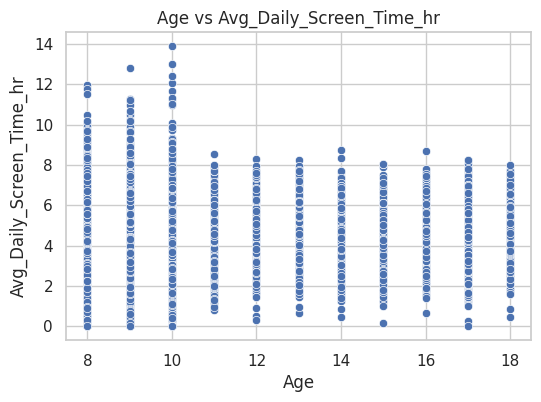

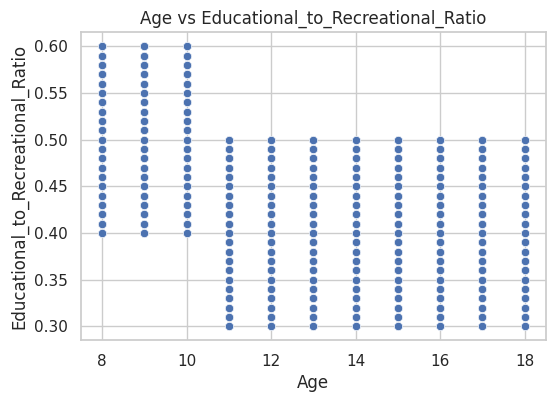

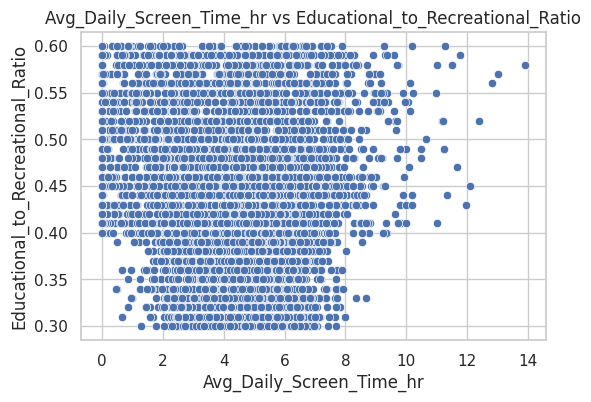

In [9]:
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[num_cols[i]], y=df[num_cols[j]])
        plt.title(f'{num_cols[i]} vs {num_cols[j]}')
        plt.show()

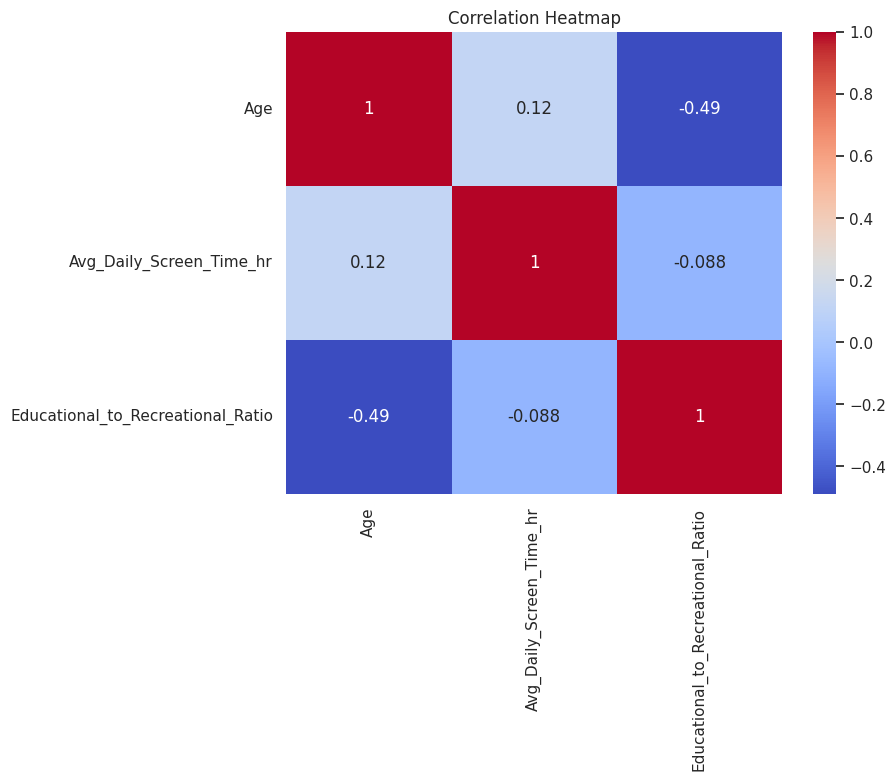

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

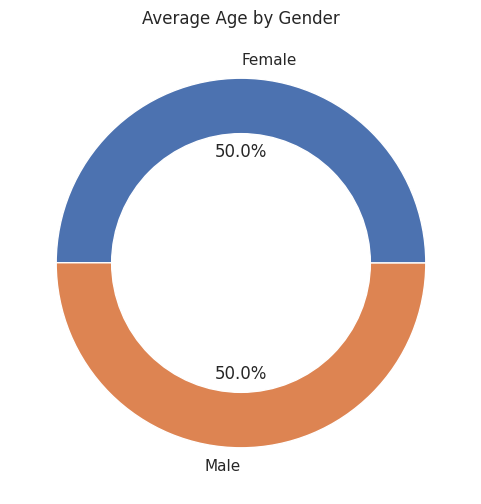

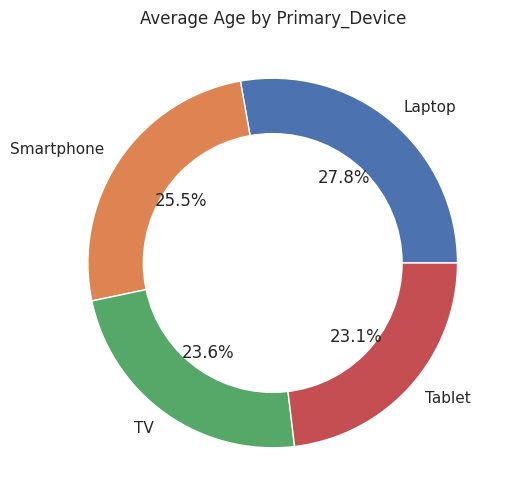

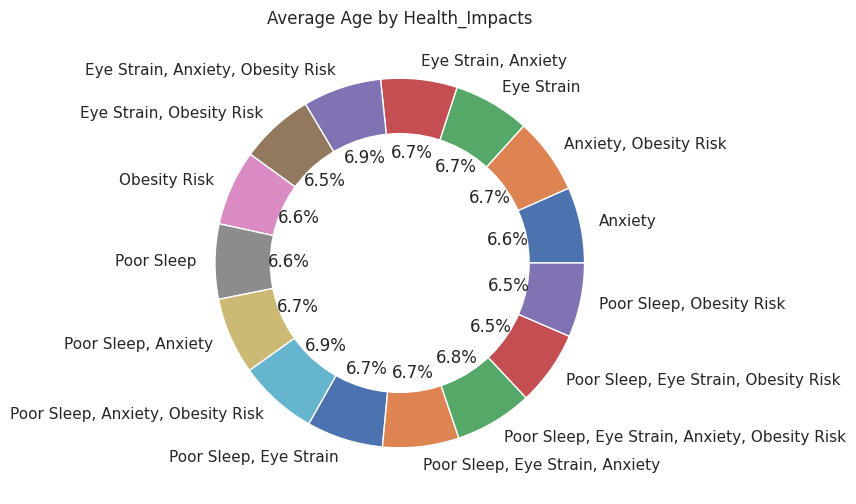

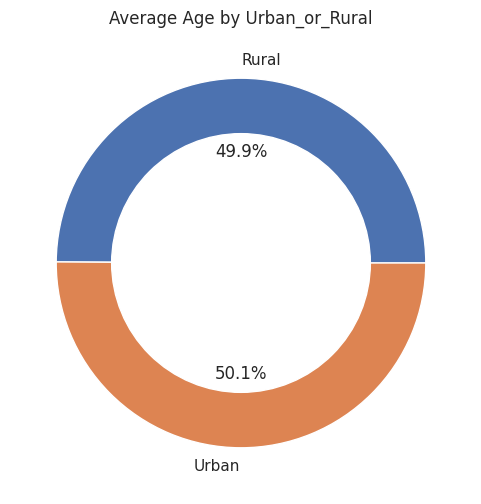

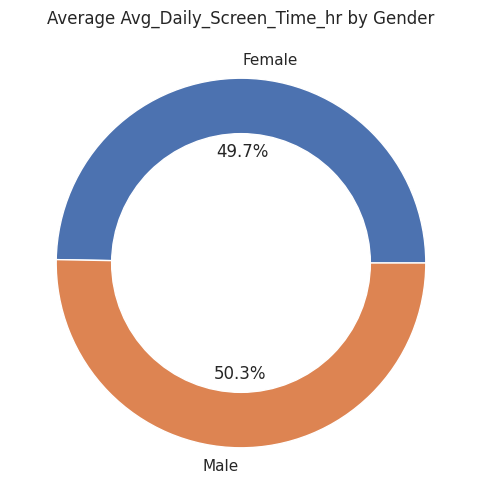

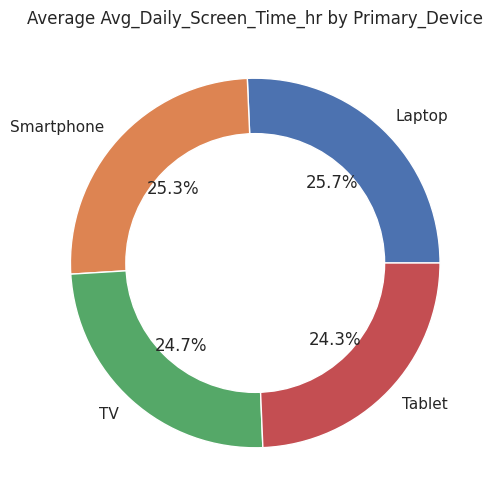

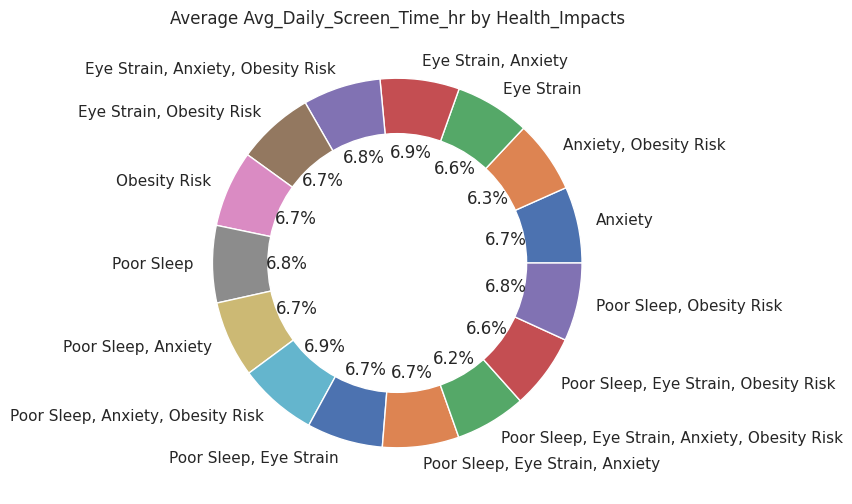

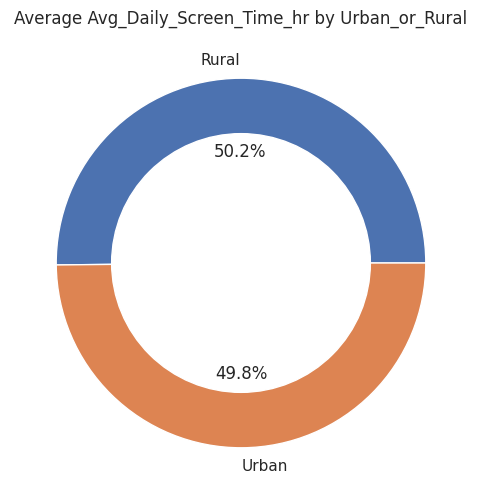

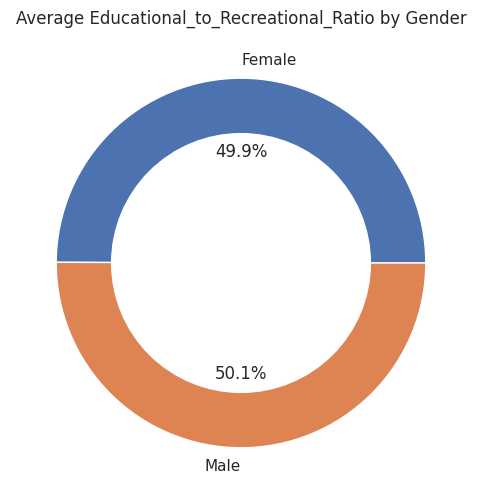

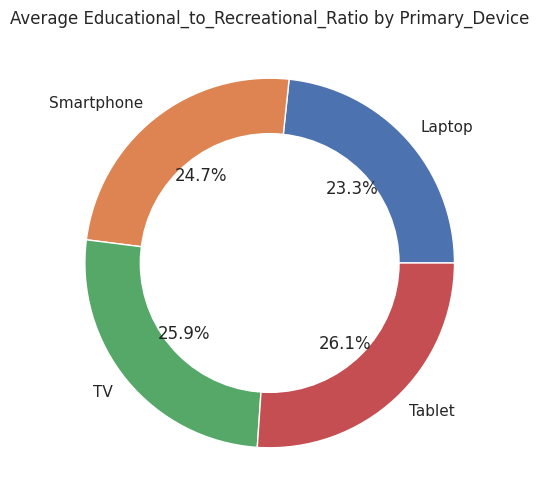

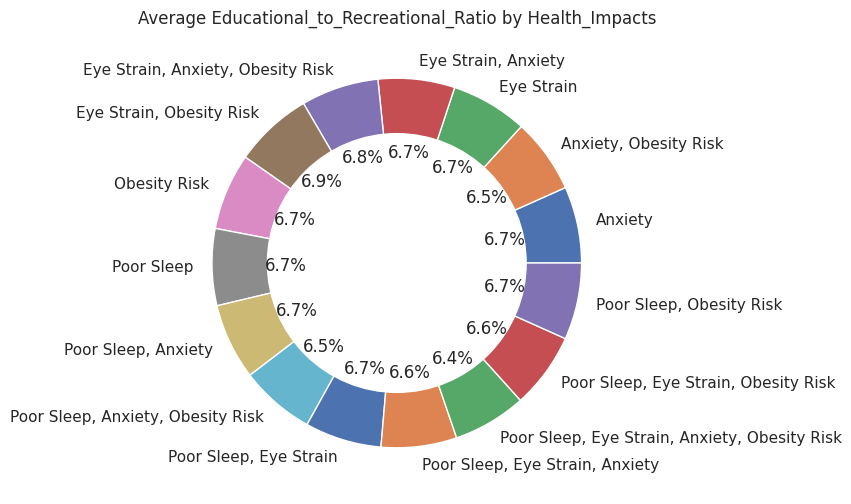

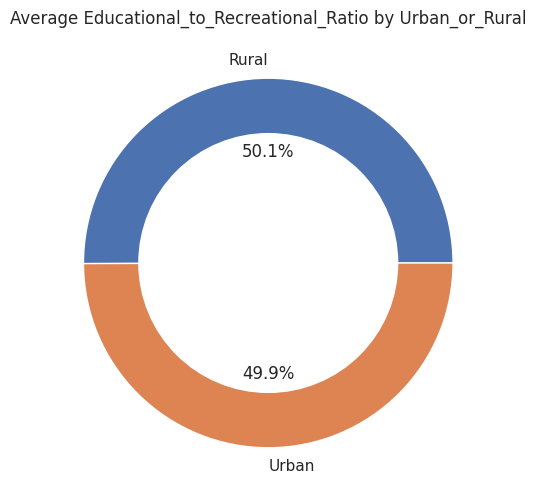

In [14]:
for num in num_cols:
    for cat in cat_cols:

        grouped = df.groupby(cat)[num].mean()

        plt.figure(figsize=(6,6))
        plt.pie(grouped, labels=grouped.index, autopct='%1.1f%%')
        centre_circle = plt.Circle((0,0),0.70,fc='white')
        fig = plt.gcf()
        fig.gca().add_artist(centre_circle)

        plt.title(f'Average {num} by {cat}')
        plt.show()

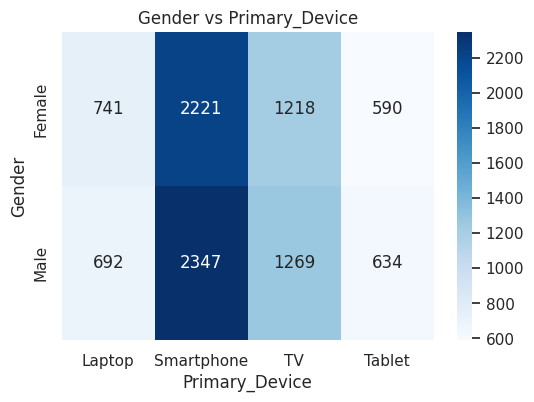

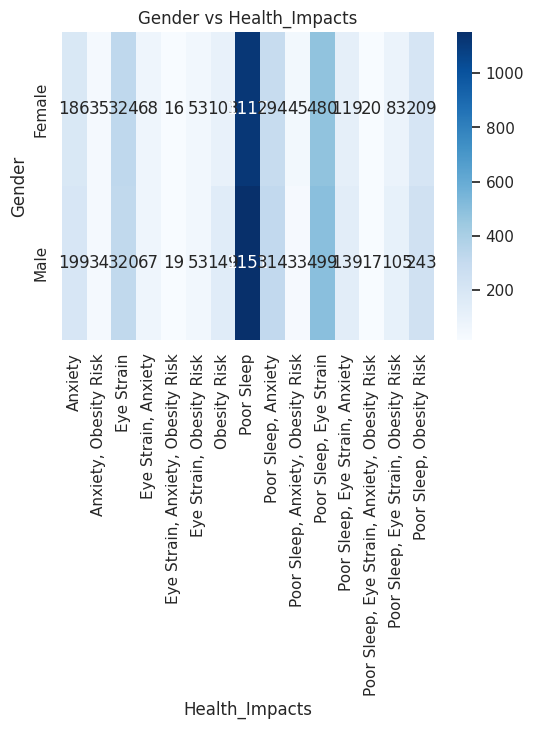

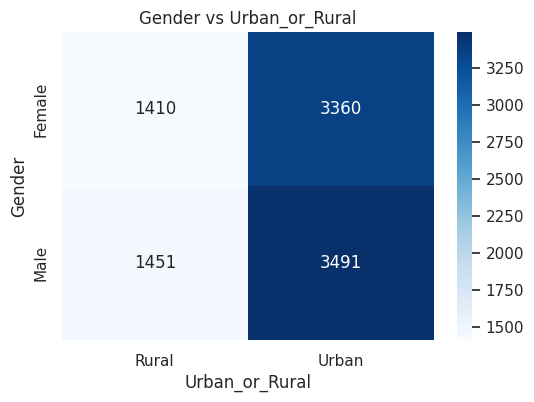

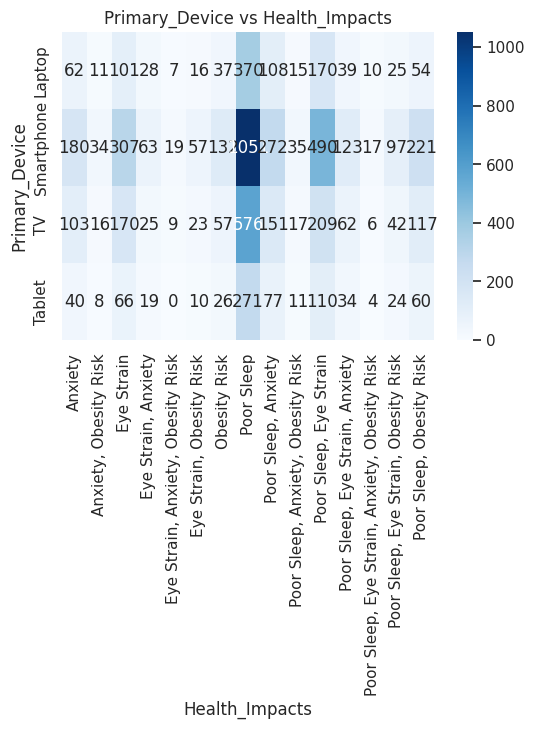

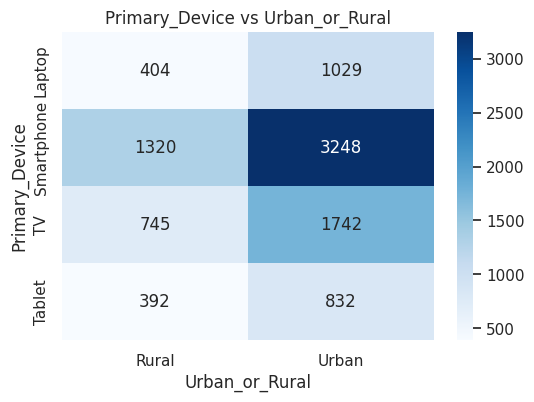

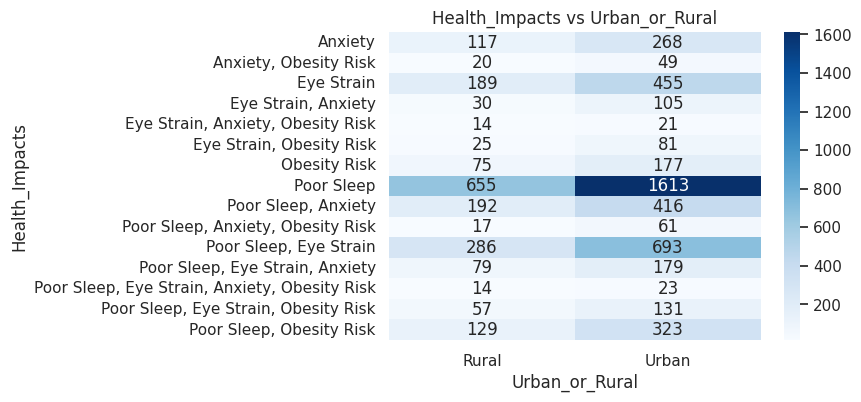

In [12]:
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        plt.figure(figsize=(6,4))
        ct = pd.crosstab(df[cat_cols[i]], df[cat_cols[j]])
        sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
        plt.title(f'{cat_cols[i]} vs {cat_cols[j]}')
        plt.show()